# 1) IRIS: K-Means + DBSCAN clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# Load Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target  # only for reference (not used in clustering)

In [3]:
# Scale
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

In [4]:
# ---- KMeans (k=3) ----
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
kmeans_labels = kmeans.fit_predict(X_iris_scaled)

In [5]:
print("IRIS - KMeans clusters:", np.unique(kmeans_labels))
print("IRIS - KMeans silhouette:", silhouette_score(X_iris_scaled, kmeans_labels))

IRIS - KMeans clusters: [0 1 2]
IRIS - KMeans silhouette: 0.4798814508199817


In [6]:
# ---- DBSCAN ----
dbscan = DBSCAN(eps=0.6, min_samples=5)  # tweak eps if needed
dbscan_labels = dbscan.fit_predict(X_iris_scaled)

In [7]:
print("\nIRIS - DBSCAN labels:", np.unique(dbscan_labels), "(note: -1 = noise)")
# Silhouette only valid if >1 cluster and no all-noise
valid = dbscan_labels != -1
if len(np.unique(dbscan_labels[valid])) > 1:
    print("IRIS - DBSCAN silhouette (non-noise):",
          silhouette_score(X_iris_scaled[valid], dbscan_labels[valid]))
else:
    print("IRIS - DBSCAN silhouette: not applicable (need >=2 clusters excluding noise)")



IRIS - DBSCAN labels: [-1  0  1] (note: -1 = noise)
IRIS - DBSCAN silhouette (non-noise): 0.6418946941661956


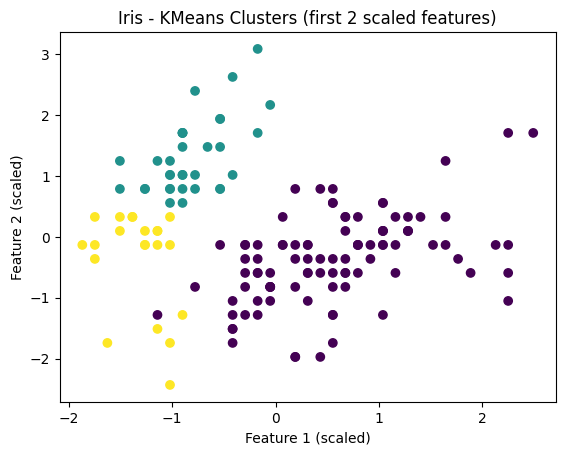

In [8]:
plt.figure()
plt.scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=kmeans_labels)
plt.title("Iris - KMeans Clusters (first 2 scaled features)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()


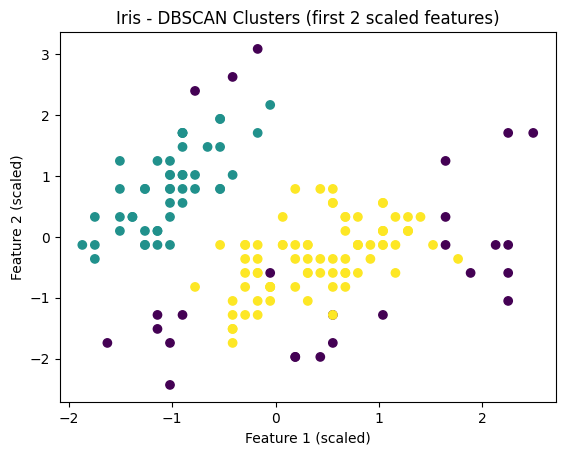

In [9]:
plt.figure()
plt.scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=dbscan_labels)
plt.title("Iris - DBSCAN Clusters (first 2 scaled features)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

# 2) WINE (from wine.csv): PCA + LDA dimensionality reduction


In [10]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [12]:
# Load Wine CSV
wine_df = pd.read_csv("wine.csv")

In [13]:
# Features / Label (assume last col is label)
X_wine = wine_df.iloc[:, :-1].values
y_wine = wine_df.iloc[:, -1].values

In [14]:
# Scale
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

In [15]:
# ---- PCA (2 components) ----
pca = PCA(n_components=2, random_state=42)
X_wine_pca = pca.fit_transform(X_wine_scaled)


In [16]:
print("\nWINE - PCA explained variance ratio:", pca.explained_variance_ratio_)
print("WINE - PCA total explained variance:", pca.explained_variance_ratio_.sum())


WINE - PCA explained variance ratio: [0.36198848 0.1920749 ]
WINE - PCA total explained variance: 0.5540633835693527


In [17]:
# ---- LDA (2 components, max is classes-1) ----
lda = LDA(n_components=2)
X_wine_lda = lda.fit_transform(X_wine_scaled, y_wine)

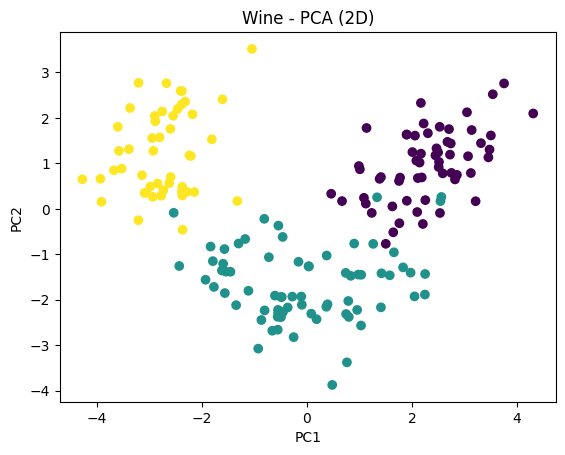

In [18]:
# Plot PCA
plt.figure()
plt.scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=y_wine)
plt.title("Wine - PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

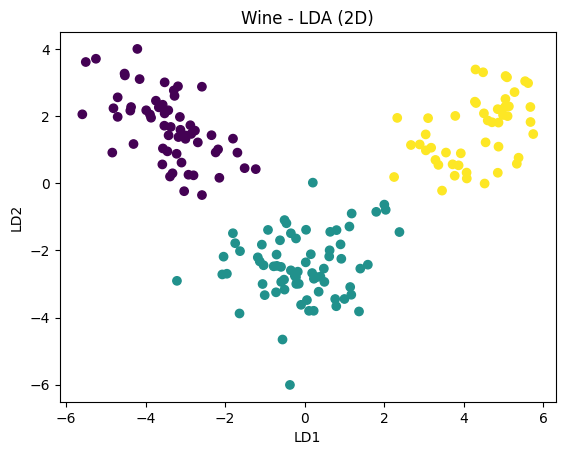

In [19]:
# Plot LDA
plt.figure()
plt.scatter(X_wine_lda[:, 0], X_wine_lda[:, 1], c=y_wine)
plt.title("Wine - LDA (2D)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

In [20]:
# Save transformed outputs (optional)
pca_out = pd.DataFrame(X_wine_pca, columns=["PC1", "PC2"])
pca_out["label"] = y_wine


In [21]:
lda_out = pd.DataFrame(X_wine_lda, columns=["LD1", "LD2"])
lda_out["label"] = y_wine

In [22]:
pca_out.to_csv("wine_pca_2d.csv", index=False)
lda_out.to_csv("wine_lda_2d.csv", index=False)

In [23]:
print("\nSaved: wine_pca_2d.csv and wine_lda_2d.csv")


Saved: wine_pca_2d.csv and wine_lda_2d.csv
